# ExProf-Bench T2: Zoo Map Test (Look-Ahead Planning under constraints)
**Kaggle AGI Hackathon 2026** | Track: Executive Functions | Google DeepMind × Kaggle

T2 evaluates **look-ahead planning under explicit constraints** using the ecological paradigm of the Zoo Map Test (BADS, Wilson et al., 1996). Each item presents a graph of locations with required stops, forbidden nodes, and sequential ordering constraints — the model must find a valid, optimal route from start to finish without breaking the rules.

What makes this computationally hard for LLMs is not the graph complexity itself, but the requirement for **global planning** while actively suppressing locally attractive shortcuts and tracking multiple simultaneous constraints across a chain of sequential decisions.

## Scoring and EPI

**Global Executive Performance Impairment (EPI):**
$$ EPI = \frac{TEI + PV + (1 - TSO) + (1 - IS) + TVR + \frac{ER + (1 - PD)}{2}}{6} $$

*Where:*
- **TEI**: Task-set Error Index (T1 - Cognitive Flexibility)
- **PV**: Protocol Violation rate (T2 - Inhibitory Control)
- **1 - TSO**: Impaired Task Sequence Optimization (T3 - Planning)
- **1 - IS**: Impaired Systematicity Index (T4 - Working Memory)
- **TVR**: Trail Violation Rate (T5 - Fluid Intelligence)
- **ER**: Spatial Error Rate / **PD**: Precision Degradation (T6 - Dual-Tasking)

*Direction:* 0 = no impairment (best), 1 = total failure (worst).

**Normative Anchor (EPI Range):**
- `< 0.20`: Healthy adult baseline (BRIEF-2A, n=1,637)
- `0.20 - 0.40`: Executive borderline zone
- `> 0.40`: Mild to severe executive dysfunction

### 3. Global passing criteria (>= 0.70 pass rate)
To achieve a passing metric and demonstrate analytical competence without an Executive Performance Impairment, the model must successfully process the items with an overall score greater than or equal to **70%**.





### 4. Mathematical Implementation
The internal evaluation loop dissects the Dual-Task paradigm into two distinct computational vectors. It aggregates the raw spatial tracking error (`ER`), adds the concurrent precision degradation penalty (`1.0 - math_accuracy`), and divides the sum by two to equally weight both coordinates of the visuospatial breakdown: `[ER + (1 - PD)] / 2`.

In [1]:
# [AUTOGENERATED] Clear Kaggle SDK cache to force live evaluation
!rm -f *.run.json *.task.json *.png

import kaggle_benchmarks as kbench
import re, json as _jj, os as _os
from collections import defaultdict
try:
    import matplotlib
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'matplotlib', '-q'])
GLOBAL_RESULTS = []
EF_DIMENSION = {
    'NONE':                        'Look-Ahead Planning',
    'LOOKAHEAD_BOTTLENECK':        'Look-Ahead Planning',
    'LOOK_AHEAD_BOTTLENECK':       'Look-Ahead Planning',
    'LONG_LOOK_AHEAD':             'Look-Ahead Planning',
    'REVERSE_PLANNING':            'Look-Ahead Planning',
    'INHIBITORY_DEADEND':          'Inhibitory Control',
    'DOMINANT_RESPONSE_INHIBITION':'Inhibitory Control',
    'DOUBLE_DEAD_END':             'Inhibitory Control',
    'TRIPLE_INHIBITION':           'Inhibitory Control',
    'WM_OVERLOAD':                 'Working Memory',
    'WM_SEQUENTIAL':               'Working Memory',
    'WM_OVERLOAD_AND_DEAD_END':    'Working Memory',
    'MAX_WM_LOAD':                 'Working Memory',
    'SEMANTIC_INTERFERENCE':       'Semantic Inhibition',
    'SEMANTIC_AND_FALSE_SHORTCUT': 'Semantic Inhibition',
    'SEMANTIC_AND_WM':             'Semantic Inhibition',
    'PERSEVERATION_LOOP':          'Perseveration Monitoring',
    'ALL_TRAPS_COMBINED':          'Combined Executive Load',
}
print('ExProf-Bench T2 Final — Executive Functions Benchmark ready.')



ExProf-Bench T2 Final — Executive Functions Benchmark ready.


In [2]:
ALL_TASKS_DATA = [
  {
    "id": "zoomap001",
    "name": "ExProf-Bench T2 Final Planning Baseline Hard",
    "cognitive_trap": "NONE",
    "difficulty": "HARD",
    "start": "Entrance",
    "end": "Exit",
    "required": [
      "Lions",
      "Elephants",
      "Reptiles"
    ],
    "forbidden": [],
    "graph": {
      "Entrance": [
        "Lions",
        "Restroom"
      ],
      "Restroom": [
        "Entrance"
      ],
      "Lions": [
        "Entrance",
        "Elephants",
        "Cafe"
      ],
      "Elephants": [
        "Lions",
        "Reptiles"
      ],
      "Cafe": [
        "Lions",
        "Reptiles",
        "Exit"
      ],
      "Reptiles": [
        "Elephants",
        "Cafe",
        "Exit"
      ],
      "Exit": [
        "Cafe",
        "Reptiles"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap002",
    "name": "ExProf-Bench T2 Final Planning Semantic House",
    "cognitive_trap": "SEMANTIC_INTERFERENCE",
    "difficulty": "VERY_HARD",
    "start": "Hall",
    "end": "Garden",
    "required": [
      "Kitchen",
      "Bedroom",
      "Study"
    ],
    "forbidden": [
      "Pantry",
      "Garage"
    ],
    "graph": {
      "Hall": [
        "Kitchen",
        "LivingRoom"
      ],
      "Kitchen": [
        "Hall",
        "Pantry",
        "LivingRoom"
      ],
      "LivingRoom": [
        "Hall",
        "Bedroom",
        "Kitchen"
      ],
      "Bedroom": [
        "LivingRoom",
        "Bathroom",
        "Study"
      ],
      "Pantry": [
        "Kitchen",
        "Garden"
      ],
      "Bathroom": [
        "Bedroom",
        "Garden"
      ],
      "Study": [
        "Bedroom",
        "Garden"
      ],
      "Garage": [
        "Hall",
        "Garden"
      ],
      "Garden": [
        "Bathroom",
        "Pantry",
        "Study",
        "Garage"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap003",
    "name": "ExProf-Bench T2 Final Planning Diverging Dead Ends Enhanced",
    "cognitive_trap": "INHIBITORY_DEADEND",
    "difficulty": "VERY_HARD",
    "start": "Gate",
    "end": "Exit",
    "required": [
      "Forest",
      "Ridge",
      "Lake"
    ],
    "forbidden": [],
    "graph": {
      "Gate": [
        "Forest",
        "SwampPath",
        "Observatory"
      ],
      "Observatory": [
        "Gate"
      ],
      "SwampPath": [
        "Gate",
        "Lake"
      ],
      "Forest": [
        "Gate",
        "River",
        "Lookout"
      ],
      "Lookout": [
        "Forest"
      ],
      "River": [
        "Forest",
        "Ridge",
        "Lake"
      ],
      "Ridge": [
        "River",
        "Peak",
        "Lake"
      ],
      "Peak": [
        "Ridge"
      ],
      "Lake": [
        "SwampPath",
        "River",
        "Ridge",
        "Exit"
      ],
      "Exit": [
        "Lake"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap004",
    "name": "ExProf-Bench T2 Final Planning Dual Forbidden",
    "cognitive_trap": "DOMINANT_RESPONSE_INHIBITION",
    "difficulty": "VERY_HARD",
    "start": "Entrance",
    "end": "Exit",
    "required": [
      "Cafe",
      "Reptiles",
      "Birds"
    ],
    "forbidden": [
      "Monkeys",
      "ShortCut"
    ],
    "graph": {
      "Entrance": [
        "Monkeys",
        "Lions",
        "ShortCut"
      ],
      "Monkeys": [
        "Entrance",
        "Reptiles"
      ],
      "ShortCut": [
        "Entrance",
        "Exit"
      ],
      "Lions": [
        "Entrance",
        "Elephants",
        "Birds"
      ],
      "Elephants": [
        "Lions",
        "Cafe"
      ],
      "Birds": [
        "Lions",
        "Garden"
      ],
      "Garden": [
        "Birds",
        "Reptiles"
      ],
      "Reptiles": [
        "Monkeys",
        "Garden",
        "Cafe"
      ],
      "Cafe": [
        "Elephants",
        "Reptiles",
        "Exit"
      ],
      "Exit": [
        "Cafe",
        "ShortCut"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap005",
    "name": "ExProf-Bench T2 Final Planning WM Overload 4 Traps",
    "cognitive_trap": "WM_OVERLOAD",
    "difficulty": "HARD",
    "start": "Start",
    "end": "End",
    "required": [
      "A",
      "B",
      "C",
      "D"
    ],
    "forbidden": [],
    "graph": {
      "Start": [
        "A",
        "Bypass"
      ],
      "Bypass": [
        "Start",
        "End"
      ],
      "A": [
        "Start",
        "B",
        "Z"
      ],
      "Z": [
        "A",
        "End"
      ],
      "B": [
        "A",
        "C",
        "Y"
      ],
      "Y": [
        "B",
        "End"
      ],
      "C": [
        "B",
        "D",
        "W"
      ],
      "W": [
        "C",
        "End"
      ],
      "D": [
        "C",
        "End"
      ],
      "End": [
        "Bypass",
        "Z",
        "Y",
        "W",
        "D"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap006",
    "name": "ExProf-Bench T2 Final Planning False Shortcut Summit",
    "cognitive_trap": "LOOKAHEAD_BOTTLENECK",
    "difficulty": "VERY_HARD",
    "start": "Base",
    "end": "Summit",
    "required": [
      "Camp",
      "Ridge",
      "Glacier"
    ],
    "forbidden": [
      "Shortcut"
    ],
    "graph": {
      "Base": [
        "Camp",
        "Bridge",
        "Shortcut"
      ],
      "Shortcut": [
        "Base",
        "Summit"
      ],
      "Camp": [
        "Base",
        "Bridge"
      ],
      "Bridge": [
        "Base",
        "Camp",
        "Ridge",
        "Overhang"
      ],
      "Overhang": [
        "Bridge"
      ],
      "Ridge": [
        "Bridge",
        "Glacier",
        "Summit"
      ],
      "Glacier": [
        "Ridge",
        "IceField",
        "Summit"
      ],
      "IceField": [
        "Glacier"
      ],
      "Summit": [
        "Shortcut",
        "Ridge",
        "Glacier"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap007",
    "name": "ExProf-Bench T2 Final Planning Dual Route Lab",
    "cognitive_trap": "INHIBITORY_DEADEND",
    "difficulty": "HARD",
    "start": "In",
    "end": "Out",
    "required": [
      "Lab",
      "Server"
    ],
    "forbidden": [
      "Vent"
    ],
    "graph": {
      "In": [
        "Lab",
        "Vent"
      ],
      "Vent": [
        "In",
        "Out"
      ],
      "Lab": [
        "In",
        "Storage",
        "Server"
      ],
      "Storage": [
        "Lab",
        "Panel",
        "Server"
      ],
      "Panel": [
        "Storage"
      ],
      "Server": [
        "Lab",
        "Storage",
        "Out"
      ],
      "Out": [
        "Vent",
        "Server"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap008",
    "name": "ExProf-Bench T2 Final Planning WM 4 Required Zoo",
    "cognitive_trap": "WM_OVERLOAD",
    "difficulty": "HARD",
    "start": "Entrance",
    "end": "Exit",
    "required": [
      "Lions",
      "Reptiles",
      "Elephants",
      "Cafe"
    ],
    "forbidden": [],
    "graph": {
      "Entrance": [
        "Lions",
        "Lobby"
      ],
      "Lobby": [
        "Entrance",
        "Monkeys"
      ],
      "Lions": [
        "Entrance",
        "Elephants",
        "Cafe"
      ],
      "Monkeys": [
        "Lobby",
        "Reptiles"
      ],
      "Reptiles": [
        "Monkeys",
        "Cafe",
        "Elephants"
      ],
      "Cafe": [
        "Lions",
        "Reptiles",
        "Exit"
      ],
      "Elephants": [
        "Lions",
        "Reptiles",
        "Exit"
      ],
      "Exit": [
        "Cafe",
        "Elephants"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap009",
    "name": "ExProf-Bench T2 Final Planning WM 4 Nodes Fork",
    "cognitive_trap": "WM_OVERLOAD",
    "difficulty": "HARD",
    "start": "Gate",
    "end": "Exit",
    "required": [
      "Lake",
      "Cave",
      "Summit",
      "Forest"
    ],
    "forbidden": [],
    "graph": {
      "Gate": [
        "Lake",
        "Swamp",
        "Ridge"
      ],
      "Swamp": [
        "Gate"
      ],
      "Ridge": [
        "Gate",
        "Pinnacle"
      ],
      "Pinnacle": [
        "Ridge"
      ],
      "Lake": [
        "Gate",
        "Cave"
      ],
      "Cave": [
        "Lake",
        "Summit",
        "Peak"
      ],
      "Peak": [
        "Cave",
        "Summit"
      ],
      "Summit": [
        "Cave",
        "Peak",
        "Forest"
      ],
      "Forest": [
        "Summit",
        "Exit"
      ],
      "Exit": [
        "Forest"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap010",
    "name": "ExProf-Bench T2 Final Planning WM Dead End Tower",
    "cognitive_trap": "WM_OVERLOAD_AND_DEAD_END",
    "difficulty": "HARD",
    "start": "Start",
    "end": "Finish",
    "required": [
      "Alpha",
      "Gamma",
      "Delta",
      "Omega"
    ],
    "forbidden": [],
    "graph": {
      "Start": [
        "Alpha",
        "Beta"
      ],
      "Alpha": [
        "Start",
        "Gamma",
        "Tower",
        "Omega"
      ],
      "Beta": [
        "Start",
        "Delta"
      ],
      "Gamma": [
        "Alpha",
        "Delta",
        "Finish"
      ],
      "Delta": [
        "Beta",
        "Gamma",
        "Omega"
      ],
      "Tower": [
        "Alpha"
      ],
      "Omega": [
        "Alpha",
        "Delta",
        "Finish"
      ],
      "Finish": [
        "Gamma",
        "Omega"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap011",
    "name": "ExProf-Bench T2 Final Planning Cross-Bridge WM",
    "cognitive_trap": "WM_SEQUENTIAL",
    "difficulty": "HARD",
    "start": "Entry",
    "end": "Exit",
    "required": [
      "A",
      "D",
      "F"
    ],
    "forbidden": [],
    "graph": {
      "Entry": [
        "A",
        "B"
      ],
      "A": [
        "Entry",
        "C"
      ],
      "B": [
        "Entry",
        "D"
      ],
      "C": [
        "A",
        "D",
        "E"
      ],
      "D": [
        "B",
        "C",
        "F"
      ],
      "E": [
        "C",
        "Exit"
      ],
      "F": [
        "D",
        "Exit"
      ],
      "Exit": [
        "E",
        "F"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap012",
    "name": "ExProf-Bench T2 Final Planning Home Layout Hard",
    "cognitive_trap": "SEMANTIC_INTERFERENCE",
    "difficulty": "HARD",
    "start": "Entrance",
    "end": "Exit",
    "required": [
      "Kitchen",
      "DiningRoom",
      "Bedroom"
    ],
    "forbidden": [],
    "graph": {
      "Entrance": [
        "Hallway",
        "Garage"
      ],
      "Hallway": [
        "Entrance",
        "Bedroom",
        "Bathroom"
      ],
      "Garage": [
        "Entrance",
        "Kitchen"
      ],
      "Bedroom": [
        "Hallway",
        "Office",
        "Bathroom"
      ],
      "Bathroom": [
        "Hallway",
        "Bedroom",
        "DiningRoom"
      ],
      "Kitchen": [
        "Garage",
        "Office"
      ],
      "Office": [
        "Bedroom",
        "Kitchen",
        "Exit"
      ],
      "DiningRoom": [
        "Bathroom",
        "Exit"
      ],
      "Exit": [
        "Office",
        "DiningRoom"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap013",
    "name": "ExProf-Bench T2 Final Planning Hospital Radiology",
    "cognitive_trap": "SEMANTIC_INTERFERENCE",
    "difficulty": "HARD",
    "start": "Lobby",
    "end": "Exit",
    "required": [
      "Emergency",
      "ICU",
      "Radiology"
    ],
    "forbidden": [],
    "graph": {
      "Lobby": [
        "Reception",
        "Triage"
      ],
      "Reception": [
        "Lobby",
        "Radiology"
      ],
      "Triage": [
        "Lobby",
        "Emergency",
        "Radiology"
      ],
      "Emergency": [
        "Triage",
        "Surgery"
      ],
      "Surgery": [
        "Emergency",
        "ICU",
        "Exit"
      ],
      "ICU": [
        "Surgery",
        "Exit"
      ],
      "Radiology": [
        "Reception",
        "Triage",
        "Exit"
      ],
      "Pharmacy": [
        "Exit"
      ],
      "Exit": [
        "Surgery",
        "ICU",
        "Radiology",
        "Pharmacy"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap014",
    "name": "ExProf-Bench T2 Final Planning School No Cafeteria",
    "cognitive_trap": "SEMANTIC_INTERFERENCE",
    "difficulty": "HARD",
    "start": "Main",
    "end": "Exit",
    "required": [
      "Study",
      "Library"
    ],
    "forbidden": [
      "Cafeteria"
    ],
    "graph": {
      "Main": [
        "Gym",
        "Cafeteria"
      ],
      "Gym": [
        "Main",
        "Locker"
      ],
      "Cafeteria": [
        "Main",
        "Library"
      ],
      "Locker": [
        "Gym",
        "Study"
      ],
      "Study": [
        "Locker",
        "Library"
      ],
      "Library": [
        "Cafeteria",
        "Study",
        "Exit"
      ],
      "Exit": [
        "Library"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap015",
    "name": "ExProf-Bench T2 Final Planning Airport Shops Required",
    "cognitive_trap": "SEMANTIC_AND_FALSE_SHORTCUT",
    "difficulty": "HARD",
    "start": "CheckIn",
    "end": "Exit",
    "required": [
      "Lounge",
      "Gate",
      "Shops"
    ],
    "forbidden": [
      "InfoDesk"
    ],
    "graph": {
      "CheckIn": [
        "Security",
        "InfoDesk"
      ],
      "Security": [
        "CheckIn",
        "Lounge"
      ],
      "InfoDesk": [
        "CheckIn",
        "Shops"
      ],
      "Lounge": [
        "Security",
        "Gate"
      ],
      "Shops": [
        "InfoDesk",
        "Gate",
        "Boarding"
      ],
      "Gate": [
        "Lounge",
        "Shops",
        "Boarding"
      ],
      "Boarding": [
        "Gate",
        "Shops",
        "Exit"
      ],
      "Exit": [
        "Boarding"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap016",
    "name": "ExProf-Bench T2 Final Planning Triple Level Trap",
    "cognitive_trap": "DOUBLE_DEAD_END",
    "difficulty": "HARD",
    "start": "Start",
    "end": "End",
    "required": [
      "A",
      "D"
    ],
    "forbidden": [],
    "graph": {
      "Start": [
        "A",
        "B",
        "Elevator"
      ],
      "Elevator": [
        "Start",
        "UpperFloor"
      ],
      "UpperFloor": [
        "Elevator",
        "Penthouse"
      ],
      "Penthouse": [
        "UpperFloor"
      ],
      "A": [
        "Start",
        "Vault",
        "C"
      ],
      "B": [
        "Start",
        "Roof",
        "D"
      ],
      "Vault": [
        "A"
      ],
      "Roof": [
        "B"
      ],
      "C": [
        "A",
        "D",
        "End"
      ],
      "D": [
        "B",
        "C",
        "End"
      ],
      "End": [
        "C",
        "D"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap017",
    "name": "ExProf-Bench T2 Final Planning Station Hub Required",
    "cognitive_trap": "DOMINANT_RESPONSE_INHIBITION",
    "difficulty": "VERY_HARD",
    "start": "Origin",
    "end": "Destination",
    "required": [
      "Station1",
      "Hub",
      "Station2",
      "Terminal"
    ],
    "forbidden": [
      "Express"
    ],
    "graph": {
      "Origin": [
        "ShortPath",
        "LongA",
        "Express"
      ],
      "ShortPath": [
        "Origin",
        "Destination"
      ],
      "Express": [
        "Origin",
        "Hub"
      ],
      "LongA": [
        "Origin",
        "Station1"
      ],
      "Station1": [
        "LongA",
        "Hub",
        "Side1"
      ],
      "Side1": [
        "Station1"
      ],
      "Hub": [
        "Station1",
        "Station2",
        "Terminal",
        "Express"
      ],
      "Station2": [
        "Hub",
        "Terminal"
      ],
      "Terminal": [
        "Hub",
        "Station2",
        "Destination"
      ],
      "Destination": [
        "ShortPath",
        "Terminal"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap018",
    "name": "ExProf-Bench T2 Final Planning Look Ahead Hub",
    "cognitive_trap": "LOOK_AHEAD_BOTTLENECK",
    "difficulty": "VERY_HARD",
    "start": "Entry",
    "end": "Exit",
    "required": [
      "N1",
      "N2",
      "N5",
      "N6"
    ],
    "forbidden": [],
    "graph": {
      "Entry": [
        "N1",
        "N2"
      ],
      "N1": [
        "Entry",
        "N2",
        "Hub"
      ],
      "N2": [
        "Entry",
        "N1",
        "Hub"
      ],
      "Hub": [
        "N1",
        "N2",
        "N5",
        "N6"
      ],
      "N5": [
        "Hub",
        "N6",
        "Exit"
      ],
      "N6": [
        "Hub",
        "N5",
        "Exit"
      ],
      "Exit": [
        "N5",
        "N6"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap019",
    "name": "ExProf-Bench T2 Final Planning Harbor Loop",
    "cognitive_trap": "PERSEVERATION_LOOP",
    "difficulty": "HARD",
    "start": "Start",
    "end": "Exit",
    "required": [
      "Bridge",
      "East",
      "Harbor"
    ],
    "forbidden": [],
    "graph": {
      "Start": [
        "Bridge",
        "North"
      ],
      "North": [
        "Start",
        "East",
        "West"
      ],
      "West": [
        "North"
      ],
      "Bridge": [
        "Start",
        "East"
      ],
      "East": [
        "Bridge",
        "North",
        "Harbor"
      ],
      "Harbor": [
        "East",
        "Exit"
      ],
      "Exit": [
        "Harbor"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap020",
    "name": "ExProf-Bench T2 Final Planning Island Bridge Trap",
    "cognitive_trap": "REVERSE_PLANNING",
    "difficulty": "VERY_HARD",
    "start": "Pier",
    "end": "Exit",
    "required": [
      "ObsDeck",
      "IslandB"
    ],
    "forbidden": [
      "Ferry"
    ],
    "graph": {
      "Pier": [
        "IslandA",
        "Ferry"
      ],
      "IslandA": [
        "Pier",
        "ObsDeck",
        "Bridge"
      ],
      "Ferry": [
        "Pier",
        "IslandB"
      ],
      "ObsDeck": [
        "IslandA",
        "IslandB"
      ],
      "Bridge": [
        "IslandA",
        "IslandB"
      ],
      "IslandB": [
        "Ferry",
        "ObsDeck",
        "Bridge",
        "Exit"
      ],
      "Exit": [
        "IslandB"
      ]
    },
    "ordered": []
  },
  {
    "id": "zoomap021",
    "name": "ExProf-Bench T2 Final Planning Long Path 4",
    "cognitive_trap": "LONG_LOOK_AHEAD",
    "difficulty": "VERY_HARD",
    "start": "S",
    "end": "End",
    "required": [
      "C",
      "E",
      "G",
      "H"
    ],
    "forbidden": [],
    "graph": {
      "S": [
        "A",
        "B"
      ],
      "A": [
        "S",
        "C",
        "D"
      ],
      "B": [
        "S",
        "E"
      ],
      "C": [
        "A",
        "F"
      ],
      "D": [
        "A",
        "G"
      ],
      "E": [
        "B",
        "G"
      ],
      "F": [
        "C",
        "H"
      ],
      "G": [
        "D",
        "E",
        "H"
      ],
      "H": [
        "F",
        "G",
        "End"
      ],
      "End": [
        "H"
      ]
    },
    "ordered": [
      [
        "C",
        "H"
      ]
    ]
  },
  {
    "id": "zoomap022",
    "name": "ExProf-Bench T2 Final Planning Semantic WM 3req",
    "cognitive_trap": "SEMANTIC_AND_WM",
    "difficulty": "VERY_HARD",
    "start": "Front",
    "end": "Exit",
    "required": [
      "Pantry",
      "Kitchen",
      "Bedroom"
    ],
    "forbidden": [],
    "graph": {
      "Front": [
        "LivingRoom",
        "Garage"
      ],
      "LivingRoom": [
        "Front",
        "DiningRoom",
        "Stairs"
      ],
      "Garage": [
        "Front",
        "Pantry"
      ],
      "DiningRoom": [
        "LivingRoom",
        "Kitchen",
        "Patio"
      ],
      "Stairs": [
        "LivingRoom",
        "Bedroom"
      ],
      "Pantry": [
        "Garage",
        "Patio"
      ],
      "Kitchen": [
        "DiningRoom",
        "Bedroom",
        "Exit"
      ],
      "Patio": [
        "DiningRoom",
        "Pantry",
        "Exit"
      ],
      "Bedroom": [
        "Stairs",
        "Kitchen",
        "Exit"
      ],
      "Exit": [
        "Kitchen",
        "Patio",
        "Bedroom"
      ]
    },
    "ordered": [
      [
        "Pantry",
        "Kitchen"
      ]
    ]
  },
  {
    "id": "zoomap023",
    "name": "ExProf-Bench T2 Final Planning Triple Inhibition Hub",
    "cognitive_trap": "TRIPLE_INHIBITION",
    "difficulty": "VERY_HARD",
    "start": "Origin",
    "end": "Dest",
    "required": [
      "P1",
      "P2",
      "P3"
    ],
    "forbidden": [
      "Shortcut"
    ],
    "graph": {
      "Origin": [
        "P1",
        "T1",
        "Shortcut"
      ],
      "T1": [
        "Origin"
      ],
      "Shortcut": [
        "Origin",
        "Dest"
      ],
      "P1": [
        "Origin",
        "P2",
        "T2"
      ],
      "T2": [
        "P1"
      ],
      "P2": [
        "P1",
        "P3",
        "T3",
        "Hub"
      ],
      "T3": [
        "P2"
      ],
      "Hub": [
        "P2",
        "Dest"
      ],
      "P3": [
        "P2",
        "Dest"
      ],
      "Dest": [
        "P3",
        "Hub",
        "Shortcut"
      ]
    },
    "ordered": [
      [
        "P1",
        "P2"
      ]
    ]
  },
  {
    "id": "zoomap024",
    "name": "ExProf-Bench T2 Final Planning Max WM Express Trap",
    "cognitive_trap": "MAX_WM_LOAD",
    "difficulty": "EXTREME",
    "start": "In",
    "end": "Out",
    "required": [
      "R1",
      "R2",
      "R3",
      "R4",
      "R5"
    ],
    "forbidden": [
      "Express"
    ],
    "graph": {
      "In": [
        "R1",
        "X1"
      ],
      "R1": [
        "In",
        "R2",
        "X2"
      ],
      "X1": [
        "In",
        "X2"
      ],
      "R2": [
        "R1",
        "R3",
        "X3"
      ],
      "X2": [
        "R1",
        "X1",
        "X3"
      ],
      "R3": [
        "R2",
        "R4",
        "Express",
        "DeadC"
      ],
      "DeadC": [
        "R3"
      ],
      "Express": [
        "R3",
        "Out"
      ],
      "X3": [
        "R2",
        "X2",
        "R5"
      ],
      "R4": [
        "R3",
        "R5",
        "Out"
      ],
      "R5": [
        "X3",
        "R4",
        "Out"
      ],
      "Out": [
        "R4",
        "R5",
        "Express"
      ]
    },
    "ordered": [
      [
        "R1",
        "R2"
      ]
    ]
  },
  {
    "id": "zoomap025",
    "name": "ExProf-Bench T2 Final Planning Final Boss Hard",
    "cognitive_trap": "ALL_TRAPS_COMBINED",
    "difficulty": "EXTREME",
    "start": "Entrance",
    "end": "Exit",
    "required": [
      "Market",
      "Warehouse",
      "Kitchen"
    ],
    "forbidden": [
      "Alley",
      "Vault"
    ],
    "graph": {
      "Entrance": [
        "Plaza",
        "Alley"
      ],
      "Plaza": [
        "Entrance",
        "Market"
      ],
      "Alley": [
        "Entrance",
        "Warehouse"
      ],
      "Market": [
        "Plaza",
        "Hub"
      ],
      "Warehouse": [
        "Alley",
        "Hub",
        "Kitchen"
      ],
      "Hub": [
        "Market",
        "Warehouse",
        "Kitchen",
        "Vault",
        "Exit"
      ],
      "Kitchen": [
        "Hub",
        "Warehouse",
        "Exit"
      ],
      "Vault": [
        "Hub"
      ],
      "Exit": [
        "Hub",
        "Kitchen"
      ]
    },
    "ordered": [
      [
        "Market",
        "Warehouse"
      ]
    ]
  },
  {
    "id": "zoomap026",
    "name": "ExProf-Bench T2 Final Planning Fork Road Choice",
    "cognitive_trap": "DOUBLE_DEAD_END",
    "difficulty": "VERY_HARD",
    "start": "Alpha",
    "end": "Omega",
    "required": [
      "Beta",
      "Gamma",
      "Delta"
    ],
    "forbidden": [],
    "graph": {
      "Alpha": [
        "Beta",
        "DecoyA",
        "DecoyB"
      ],
      "DecoyA": [
        "Alpha"
      ],
      "DecoyB": [
        "Alpha",
        "DeepDecoy"
      ],
      "DeepDecoy": [
        "DecoyB"
      ],
      "Beta": [
        "Alpha",
        "Gamma",
        "Epsilon"
      ],
      "Epsilon": [
        "Beta",
        "Delta"
      ],
      "Gamma": [
        "Beta",
        "Delta"
      ],
      "Delta": [
        "Gamma",
        "Epsilon",
        "Omega",
        "DecoyD"
      ],
      "DecoyD": [
        "Delta"
      ],
      "Omega": [
        "Delta"
      ]
    },
    "ordered": [
      [
        "Beta",
        "Gamma"
      ]
    ]
  },
  {
    "id": "zoomap027",
    "name": "ExProf-Bench T2 Final Planning All Traps Gauntlet",
    "cognitive_trap": "ALL_TRAPS_COMBINED",
    "difficulty": "EXTREME",
    "start": "Entry",
    "end": "Exit",
    "required": [
      "Alpha",
      "Beta",
      "Gamma"
    ],
    "forbidden": [
      "Forbidden",
      "Tunnel"
    ],
    "graph": {
      "Entry": [
        "Alpha",
        "Forbidden",
        "Tunnel"
      ],
      "Forbidden": [
        "Entry",
        "Beta"
      ],
      "Tunnel": [
        "Entry"
      ],
      "Alpha": [
        "Entry",
        "Beta",
        "Pit"
      ],
      "Pit": [
        "Alpha"
      ],
      "Beta": [
        "Forbidden",
        "Alpha",
        "Gamma",
        "Bunker"
      ],
      "Bunker": [
        "Beta"
      ],
      "Gamma": [
        "Beta",
        "Exit",
        "Vault"
      ],
      "Vault": [
        "Gamma"
      ],
      "Exit": [
        "Gamma"
      ]
    },
    "ordered": [
      [
        "Alpha",
        "Beta"
      ]
    ]
  },
  {
    "id": "zoomap028",
    "name": "ExProf-Bench T2 Final Planning Dense Neighborhood",
    "cognitive_trap": "PERSEVERATION_LOOP",
    "difficulty": "VERY_HARD",
    "start": "Home",
    "end": "School",
    "required": [
      "Park",
      "Library",
      "Mall"
    ],
    "forbidden": [],
    "graph": {
      "Home": [
        "Park",
        "Cinema",
        "Hotel"
      ],
      "Cinema": [
        "Home",
        "Hotel"
      ],
      "Hotel": [
        "Home",
        "Cinema",
        "Park"
      ],
      "Park": [
        "Home",
        "Hotel",
        "Library",
        "Mall"
      ],
      "Library": [
        "Park",
        "Mall",
        "School"
      ],
      "Mall": [
        "Park",
        "Library",
        "School"
      ],
      "School": [
        "Library",
        "Mall"
      ]
    },
    "ordered": [
      [
        "Park",
        "Library"
      ]
    ]
  },
  {
    "id": "zoomap029",
    "name": "ExProf-Bench T2 Final Planning Port Bottleneck Hard",
    "cognitive_trap": "LOOK_AHEAD_BOTTLENECK",
    "difficulty": "HARD",
    "start": "Port",
    "end": "City",
    "required": [
      "Dock",
      "Canal",
      "Marina"
    ],
    "forbidden": [
      "FastPath"
    ],
    "graph": {
      "Port": [
        "Dock",
        "FastPath"
      ],
      "FastPath": [
        "Port",
        "City"
      ],
      "Dock": [
        "Port",
        "Canal",
        "Warehouse"
      ],
      "Warehouse": [
        "Dock",
        "Loading"
      ],
      "Loading": [
        "Warehouse",
        "Canal"
      ],
      "Canal": [
        "Dock",
        "Loading",
        "Marina"
      ],
      "Marina": [
        "Canal",
        "Berth",
        "City"
      ],
      "Berth": [
        "Marina"
      ],
      "City": [
        "FastPath",
        "Marina"
      ]
    },
    "ordered": [
      [
        "Dock",
        "Canal"
      ]
    ]
  },
  {
    "id": "zoomap030",
    "name": "ExProf-Bench T2 Final Planning Depot 5 Req Traps",
    "cognitive_trap": "WM_OVERLOAD",
    "difficulty": "VERY_HARD",
    "start": "Depot",
    "end": "Warehouse",
    "required": [
      "SecA",
      "SecB",
      "SecC",
      "SecD",
      "SecE"
    ],
    "forbidden": [
      "Bypass",
      "Express1",
      "Express2"
    ],
    "graph": {
      "Depot": [
        "SecA",
        "Bypass",
        "Express1"
      ],
      "Bypass": [
        "Depot",
        "Warehouse"
      ],
      "Express1": [
        "Depot",
        "SecC"
      ],
      "SecA": [
        "Depot",
        "SecB",
        "DeadA"
      ],
      "DeadA": [
        "SecA"
      ],
      "SecB": [
        "SecA",
        "SecC"
      ],
      "SecC": [
        "SecB",
        "SecD",
        "Express2",
        "DeadC"
      ],
      "DeadC": [
        "SecC"
      ],
      "Express2": [
        "SecC",
        "Warehouse"
      ],
      "SecD": [
        "SecC",
        "SecE"
      ],
      "SecE": [
        "SecD",
        "Warehouse"
      ],
      "Warehouse": [
        "Bypass",
        "SecE",
        "Express2"
      ]
    },
    "ordered": [
      [
        "SecA",
        "SecB"
      ]
    ]
  }
]
print('Dataset: ' + str(len(ALL_TASKS_DATA)) + ' items loaded.')


import json as _jj
from collections import deque

Dataset: 30 items loaded.


In [3]:
SC_WORDS = ['actually', 'wait,', 'correction', 'my mistake', 'revised route', 'corrijo', 'rectifico']
def _clean(t):
    return ''.join(ch for ch in t.strip() if ch.isalnum() or ch == '_')
def _extract_route(text):
    i = text.find('['); j = text.find(']', i) if i != -1 else -1
    if i != -1 and j != -1:
        try:
            p = _jj.loads(text[i:j+1])
            if isinstance(p, list) and all(isinstance(x, str) for x in p):
                return [x.strip() for x in p if x.strip()]
        except: pass
    if '->' in text:
        r = [_clean(p) for p in text.split('->') if _clean(p)]
        if len(r) >= 2: return r
    for line in text.splitlines():
        if ',' in line:
            parts = [_clean(p) for p in line.split(',') if _clean(p)]
            if len(parts) >= 2: return parts
    return []
def _self_corrected(text):
    low = text.lower()
    return any(kw in low for kw in SC_WORDS)
def find_optimal_length(item):
    start, end_node = item['start'], item['end']
    required = frozenset(item['required'])
    forbidden = set(item['forbidden'])
    graph = item['graph']
    init_vis = frozenset([start])
    queue = deque([(start, init_vis, 1)])
    seen = {(start, init_vis)}
    while queue:
        node, vis, length = queue.popleft()
        if node == end_node and required <= vis:
            return length
        for nb in graph.get(node, []):
            if nb in forbidden or nb in vis: continue
            nv = vis | frozenset([nb])
            st = (nb, nv)
            if st not in seen:
                seen.add(st)
                queue.append((nb, nv, length + 1))
    return None
def evaluate(response, item):
    if _self_corrected(response): return 0.0, 'self_correction'
    route = _extract_route(response)
    if len(route) < 2: return 0.0, 'no_valid_route'
    if route[0] != item['start']: return 0.0, 'wrong_start:' + str(route[0])
    if route[-1] != item['end']: return 0.0, 'wrong_end:' + str(route[-1])
    visited = []
    for a, b in zip(route, route[1:]):
        if a not in item['graph']: return 0.0, 'unknown_node:' + a
        if b not in item['graph'][a]: return 0.0, 'invalid_edge:' + a + '->' + b
        if a in visited: return 0.0, 'cycle_at:' + a
        visited.append(a)
    visited.append(route[-1])
    
    score = 1.0
    for O_A, O_B in item.get('ordered', []):
        if O_A in visited and O_B in visited:
            if visited.index(O_A) >= visited.index(O_B):
                return 0.1, 'sequence_violation:' + O_A + '_must_be_before_' + O_B
    for n in item['forbidden']:
        if n in visited: return 0.1, 'forbidden:' + n
    missing = set(item['required']) - set(visited)
    if missing:
        penalty = 0.3 * len(missing)
        score = max(0.2, score - penalty)
        return score, 'missing:' + str(sorted(missing))
    optimal = find_optimal_length(item)
    if optimal is not None and len(route) > optimal:
        return 0.0, 'not_optimal:model=' + str(len(route)) + '_best=' + str(optimal)
    return score, 'ok'
def build_prompt(item):
    lines = ['You are solving a route planning task.', '', 'Map connections:']
    for node, nbrs in sorted(item['graph'].items()):
        lines.append('  ' + node + ': ' + ', '.join(nbrs))
    req  = ', '.join(item['required'])  if item['required']  else 'none'
    forb = ', '.join(item['forbidden']) if item['forbidden'] else 'none'
    lines += ['', 'Start at : ' + item['start'], 'End at   : ' + item['end'],
              'MUST visit (all): ' + req, 'MUST NOT visit  : ' + forb, '']
    if item.get('ordered'):
        lines.append('ORDER RULES: (Strict Temporal Working Memory)')
        for A, B in item['ordered']:
            lines.append('  - You MUST visit ' + A + ' BEFORE you visit ' + B)
        lines.append('')
    lines += ['Rules:', '  1. Only use direct connections shown above.',
              '  2. Do NOT revisit any node.', '  3. No explanation, final answer only.',
              '  4. Your route MUST be the SHORTEST possible valid route.',
              '', 'Respond ONLY with a JSON list e.g. ["NodeA", "NodeB", "NodeC"]']
    return chr(10).join(lines)
print('Validator + prompt builder loaded.')



Validator + prompt builder loaded.


#,Modelo,Pass Rate,EPI,Auto-correc.,Status,Timestamp
1,anthropic/claude-sonnet-4@20250514,93.3% (28/30),0.077,0,✅,2026-04-17 11:58


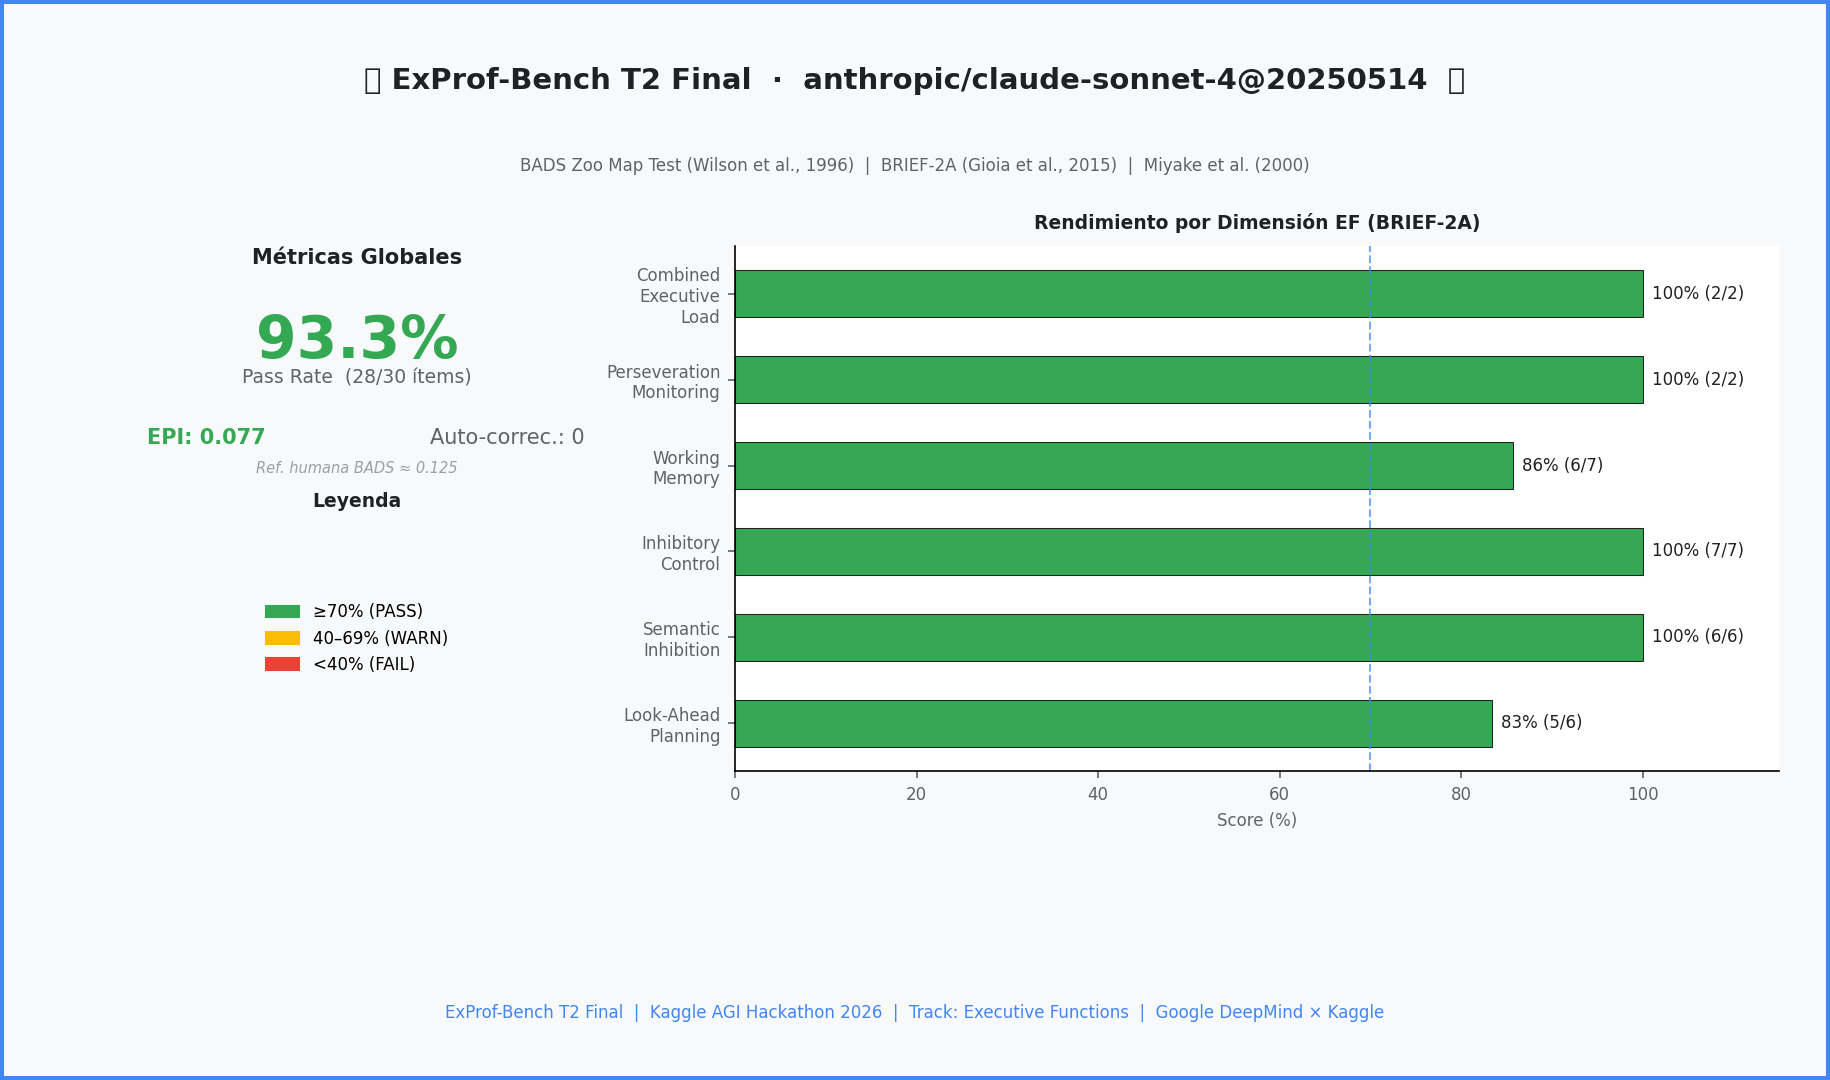

[zoomap001] Score: 1.0 | PASS
[zoomap002] Score: 1.0 | PASS
[zoomap003] Score: 1.0 | PASS
[zoomap004] Score: 1.0 | PASS
[zoomap005] Score: 1.0 | PASS
[zoomap006] Score: 1.0 | PASS
[zoomap007] Score: 1.0 | PASS
[zoomap008] Score: 0.0 | FAIL
  reason: not_optimal:model=8_best=6
[zoomap009] Score: 1.0 | PASS
[zoomap010] Score: 1.0 | PASS
[zoomap011] Score: 1.0 | PASS
[zoomap012] Score: 1.0 | PASS
[zoomap013] Score: 0.7 | PASS
  reason: missing:['Radiology']
[zoomap014] Score: 1.0 | PASS
[zoomap015] Score: 1.0 | PASS
[zoomap016] Score: 1.0 | PASS
[zoomap017] Score: 1.0 | PASS
[zoomap018] Score: 1.0 | PASS
[zoomap019] Score: 1.0 | PASS
[zoomap020] Score: 1.0 | PASS
[zoomap021] Score: 0.0 | FAIL
  reason: invalid_edge:E->End
[zoomap022] Score: 1.0 | PASS
[zoomap023] Score: 1.0 | PASS
[zoomap024] Score: 1.0 | PASS
[zoomap025] Score: 1.0 | PASS
[zoomap026] Score: 1.0 | PASS
[zoomap027] Score: 1.0 | PASS
[zoomap028] Score: 1.0 | PASS
[zoomap029] Score: 1.0 | PASS
[zoomap030] Score: 1.0 | PASS


Wrong return type <class 'float'>. Expected None | kaggle_benchmarks.results.Unknown. This may need to lead to unexpected task behavior.


Run(task=Task(func=<function task_exprof_bench_t2_final at 0x7e2a4023ae80>, name='ExProf T2: Zoo Map (Look-Ahead Planning)', description='EF: 30 planning tasks across 6 dimensions. PASS threshold: 70 pct optimal.', result_type=<class 'kaggle_benchmarks.results.PassFail'>, version=1, store_task=True, store_run=True), result=0.9333333333333333, chat=Chat(history=[Message(content='You are solving a route planning task.\n\nMap connections:\n  Cafe: Lions, Reptiles, Exit\n  Elephants: Lions, Reptiles\n  Entrance: Lions, Restroom\n  Exit: Cafe, Reptiles\n  Lions: Entrance, Elephants, Cafe\n  Reptiles: Elephants, Cafe, Exit\n  Restroom: Entrance\n\nStart at : Entrance\nEnd at   : Exit\nMUST visit (all): Lions, Elephants, Reptiles\nMUST NOT visit  : none\n\nRules:\n  1. Only use direct connections shown above.\n  2. Do NOT revisit any node.\n  3. No explanation, final answer only.\n  4. Your route MUST be the SHORTEST possible valid route.\n\nRespond ONLY with a JSON list e.g. ["NodeA", "NodeB", "NodeC"]', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='["Entrance", "Lions", "Elephants", "Reptiles", "Exit"]', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 210, 'output_tokens': 23, 'input_tokens_cost_nanodollars': 630000, 'output_tokens_cost_nanodollars': 345000, 'total_backend_latency_ms': 1056, 'chat': ..., 'schema': <class 'str'>, 'raw_content': '["Entrance", "Lions", "Elephants", "Reptiles", "Exit"]', 'seed': 0, 'temperature': None, 'tools': []}), Message(content='You are solving a route planning task.\n\nMap connections:\n  Bathroom: Bedroom, Garden\n  Bedroom: LivingRoom, Bathroom, Study\n  Garage: Hall, Garden\n  Garden: Bathroom, Pantry, Study, Garage\n  Hall: Kitchen, LivingRoom\n  Kitchen: Hall, Pantry, LivingRoom\n  LivingRoom: Hall, Bedroom, Kitchen\n  Pantry: Kitchen, Garden\n  Study: Bedroom, Garden\n\nStart at : Hall\nEnd at   : Garden\nMUST visit (all): Kitchen, Bedroom, Study\nMUST NOT visit  : Pantry, Garage\n\nRules:\n  1. Only use direct connections shown above.\n  2. Do NOT revisit any node.\n  3. No explanation, final answer only.\n  4. Your route MUST be the SHORTEST possible valid route.\n\nRespond ONLY with a JSON list e.g. ["NodeA", "NodeB", "NodeC"]', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='["Hall", "Kitchen", "LivingRoom", "Bedroom", "Study", "Garden"]', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 462, 'output_tokens': 25, 'input_tokens_cost_nanodollars': 1386000, 'output_tokens_cost_nanodollars': 375000, 'total_backend_latency_ms': 695, 'chat': ..., 'schema': <class 'str'>, 'raw_content': '["Hall", "Kitchen", "LivingRoom", "Bedroom", "Study", "Garden"]', 'seed': 0, 'temperature': None, 'tools': []}), Message(content='You are solving a route planning task.\n\nMap connections:\n  Exit: Lake\n  Forest: Gate, River, Lookout\n  Gate: Forest, SwampPath, Observatory\n  Lake: SwampPath, River, Ridge, Exit\n  Lookout: Forest\n  Observatory: Gate\n  Peak: Ridge\n  Ridge: River, Peak, Lake\n  River: Forest, Ridge, Lake\n  SwampPath: Gate, Lake\n\nStart at : Gate\nEnd at   : Exit\nMUST visit (all): Forest, Ridge, Lake\nMUST NOT visit  : none\n\nRules:\n  1. Only use direct connections shown above.\n  2. Do NOT revisit any node.\n  3. No explanation, final answer only.\n  4. Your route MUST be the SHORTEST possible valid route.\n\nRespond ONLY with a JSON list e.g. ["NodeA", "NodeB", "NodeC"]', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='["Gate", "Forest", "River", "Ridge", "Lake", "Exit"]', sender=OpenAI(name='anthropic/claude-sonnet-4@2025051

In [4]:
# ── ExProf-Bench v17 — Single aggregate task, 70% threshold assertion ────────
# NO return type → assertions determine PASS/FAIL (matches old behavior that worked).
# ONE final assert_true at 70% threshold → FAIL if model scores <70% overall.
# Individual item results printed to console + stored in GLOBAL_RESULTS.
# Cumulative leaderboard persisted to exprof_leaderboard.json.

import json as _json
import os as _os
import datetime as _datetime

LEADERBOARD_FILE = 'exprof_leaderboard.json'

def load_leaderboard():
    entries = {}
    import glob
    # 1. Cargar historial desde Kaggle datasets previos si existen
    for fpath in glob.glob('/kaggle/input/**/exprof_leaderboard.json', recursive=True):
        try:
            with open(fpath, 'r') as _f:
                data = _json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or e.get('timestamp', '') > entries[m].get('timestamp', '')):
                            entries[m] = e
        except Exception:
            pass
    # 2. Cargar/sobrescribir historial local del entorno virtual actual
    if _os.path.exists(LEADERBOARD_FILE):
        try:
            with open(LEADERBOARD_FILE, 'r') as _f:
                data = _json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or e.get('timestamp', '') > entries[m].get('timestamp', '')):
                            entries[m] = e
        except Exception:
            pass
    return list(entries.values())

def save_leaderboard(entries):
    with open(LEADERBOARD_FILE, 'w') as _f:
        _json.dump(entries, _f, indent=2)

def render_leaderboard_table(entries, current_model=None, progress=None):
    from IPython.display import HTML
    sorted_entries = sorted(entries, key=lambda x: x.get('pass_rate', 0), reverse=True)
    rows = ''
    for i, e in enumerate(sorted_entries):
        epi = e.get('epi', 1.0)
        pr  = e.get('pass_rate', 0)
        epi_color = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'
        pr_color  = '#34a853' if pr  >= 70   else '#ea4335'
        status    = '✅' if pr >= 70 else '❌'
        ts = e.get('timestamp', '')[:16].replace('T', ' ')
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">{i+1}</td>'
            f'<td style="padding:6px 8px;font-weight:bold;">{e.get("model","")}</td>'
            f'<td style="padding:6px 8px;color:{pr_color};font-weight:bold;">'
            f'{pr:.1f}% ({e.get("passed",0)}/{e.get("total",0)})</td>'
            f'<td style="padding:6px 8px;color:{epi_color};font-weight:bold;">{epi:.3f}</td>'
            f'<td style="padding:6px 8px;color:#5f6368;">{e.get("self_corrections",0)}</td>'
            f'<td style="padding:6px 8px;">{status}</td>'
            f'<td style="padding:6px 8px;font-size:11px;color:#9aa0a6;">{ts}</td>'
            f'</tr>'
        )
    if current_model is not None:
        prog_text = f'⏳ {progress} ítems' if progress else '⏳ iniciando...'
        rows += (
            f'<tr style="background:#fff8e1;border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">—</td>'
            f'<td style="padding:6px 8px;font-weight:bold;color:#f9ab00;">{current_model}</td>'
            f'<td colspan="5" style="padding:6px 8px;color:#f9ab00;">{prog_text}</td>'
            f'</tr>'
        )
    count = len(entries) + (1 if current_model is not None else 0)
    header = (
        f'<div style="background:#f8f9fa;padding:16px 20px;border-radius:10px;'
        f'border-left:6px solid #4285f4;margin:12px 0;">'
        f'<h3 style="margin:0 0 4px;color:#202124;font-size:15px;">'
        f'🧠 ExProf-Bench T2 Final — Leaderboard ({count} modelo{"s" if count!=1 else ""})</h3>'
        f'<p style="font-size:11px;color:#5f6368;margin:0 0 12px;">'
        f'BADS Zoo Map Test (Wilson et al., 1996) · BRIEF-2A · Miyake et al. (2000) · '
        f'Ref. humana BADS ≈ 0.125 EPI</p>'
        f'<table style="width:100%;border-collapse:collapse;font-size:13px;">'
        f'<thead style="background:#e8eaed;color:#202124;">'
        f'<tr>'
        f'<th style="padding:6px 8px;text-align:left;">#</th>'
        f'<th style="padding:6px 8px;text-align:left;">Modelo</th>'
        f'<th style="padding:6px 8px;text-align:left;">Pass Rate</th>'
        f'<th style="padding:6px 8px;text-align:left;">EPI</th>'
        f'<th style="padding:6px 8px;text-align:left;">Auto-correc.</th>'
        f'<th style="padding:6px 8px;text-align:left;">Status</th>'
        f'<th style="padding:6px 8px;text-align:left;">Timestamp</th>'
        f'</tr></thead>'
        f'<tbody>{rows}</tbody>'
        f'</table></div>'
    )
    return HTML(header)


def render_exprof_summary(modelo_nombre, results_list):
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning)
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    from IPython.display import display, Image
    import io

    plt.switch_backend('agg')

    total = len(results_list)
    if total == 0:
        return
    aciertos = sum(1 for r in results_list if r.get('passed', False))
    penalizaciones = sum(1 for r in results_list if r.get('self_corrected', False))
    pass_rate = (aciertos / total) * 100
    epi = round(1.0 - (sum(r.get('score', 0) for r in results_list) / total), 3)

    resumen = {}
    for r in results_list:
        trap = r.get('cognitive_trap', 'UNKNOWN')
        dim = EF_DIMENSION.get(trap, trap)
        if dim not in resumen:
            resumen[dim] = {'total': 0, 'passed': 0}
        resumen[dim]['total'] += 1
        if r.get('passed', False):
            resumen[dim]['passed'] += 1

    dims   = list(resumen.keys())
    accs   = [(resumen[d]['passed'] / resumen[d]['total']) * 100 for d in dims]
    colors = ['#34a853' if a >= 70 else '#fbbc04' if a >= 40 else '#ea4335' for a in accs]

    epi_color   = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'
    status_icon = '\u2705' if pass_rate >= 70 else '\u274c'

    fig = plt.figure(figsize=(12, 7), facecolor='#f8f9fa')
    fig.patch.set_linewidth(3)
    fig.patch.set_edgecolor('#4285f4')

    ax_header = fig.add_axes([0.0, 0.82, 1.0, 0.18], facecolor='#e8eaed')
    ax_header.axis('off')
    ax_header.text(0.5, 0.65,
        f'\U0001f9e0 ExProf-Bench T2 Final  \u00b7  {modelo_nombre}  {status_icon}',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#202124',
        transform=ax_header.transAxes)
    ax_header.text(0.5, 0.20,
        'BADS Zoo Map Test (Wilson et al., 1996)  |  BRIEF-2A (Gioia et al., 2015)  |  Miyake et al. (2000)',
        ha='center', va='center', fontsize=8, color='#5f6368',
        transform=ax_header.transAxes)

    ax_kpi = fig.add_axes([0.0, 0.58, 0.38, 0.22], facecolor='white')
    ax_kpi.axis('off')
    ax_kpi.text(0.5, 0.90, 'M\u00e9tricas Globales', ha='center', va='top',
        fontsize=10, fontweight='bold', color='#202124', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.62, f'{pass_rate:.1f}%', ha='center', va='top',
        fontsize=28, fontweight='bold',
        color='#34a853' if pass_rate >= 70 else '#ea4335',
        transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.38, f'Pass Rate  ({aciertos}/{total} \u00edtems)', ha='center', va='top',
        fontsize=9, color='#5f6368', transform=ax_kpi.transAxes)
    ax_kpi.text(0.28, 0.12, f'EPI: {epi:.3f}', ha='center', va='top',
        fontsize=10, fontweight='bold', color=epi_color, transform=ax_kpi.transAxes)
    ax_kpi.text(0.72, 0.12, f'Auto-correc.: {penalizaciones}', ha='center', va='top',
        fontsize=10, color='#5f6368', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, -0.02, 'Ref. humana BADS \u2248 0.125', ha='center', va='top',
        fontsize=7, color='#9aa0a6', style='italic', transform=ax_kpi.transAxes)

    ax_bar = fig.add_axes([0.40, 0.28, 0.58, 0.50], facecolor='white')
    y_pos = np.arange(len(dims))
    bars  = ax_bar.barh(y_pos, accs, color=colors, height=0.55,
                        edgecolor='#202124', linewidth=0.5)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels([d.replace(' ', '\n') for d in dims], fontsize=8)
    ax_bar.set_xlabel('Score (%)', fontsize=8, color='#5f6368')
    ax_bar.axvline(x=70, color='#4285f4', linestyle='--', linewidth=1, alpha=0.7)
    ax_bar.set_title('Rendimiento por Dimensi\u00f3n EF (BRIEF-2A)', fontsize=9,
                     fontweight='bold', color='#202124', pad=8)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.tick_params(axis='both', labelsize=8, colors='#5f6368')
    for bar, acc, d in zip(bars, accs, dims):
        n = resumen[d]['passed']
        t = resumen[d]['total']
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f'{acc:.0f}% ({n}/{t})', va='center', fontsize=8, color='#202124')

    ax_leg = fig.add_axes([0.0, 0.28, 0.38, 0.28], facecolor='white')
    ax_leg.axis('off')
    ax_leg.text(0.5, 0.95, 'Leyenda', ha='center', va='top',
        fontsize=9, fontweight='bold', color='#202124', transform=ax_leg.transAxes)
    patches = [
        mpatches.Patch(color='#34a853', label='\u226570% (PASS)'),
        mpatches.Patch(color='#fbbc04', label='40\u201369% (WARN)'),
        mpatches.Patch(color='#ea4335', label='<40% (FAIL)'),
    ]
    ax_leg.legend(handles=patches, loc='center', fontsize=8, frameon=False,
                  bbox_to_anchor=(0.5, 0.45))

    ax_foot = fig.add_axes([0.0, 0.0, 1.0, 0.10], facecolor='#e8f0fe')
    ax_foot.axis('off')
    ax_foot.text(0.5, 0.5,
        'ExProf-Bench T2 Final  |  Kaggle AGI Hackathon 2026  |  Track: Executive Functions  |  Google DeepMind \u00d7 Kaggle',
        ha='center', va='center', fontsize=8, color='#4285f4',
        transform=ax_foot.transAxes)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.savefig('exprof_results.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read(), format='png'))


@kbench.task(
    name='ExProf T2: Zoo Map (Look-Ahead Planning)',
    description='EF: 30 planning tasks across 6 dimensions. PASS threshold: 70 pct optimal.'
)
def task_exprof_bench_t2_final(llm):
    import time
    import io
    import sys
    from IPython.display import display, clear_output
    passed_count = 0
    scores_sum   = 0.0
    model_n = getattr(llm, 'model_name', getattr(llm, 'name', 'model'))

    # ── Load accumulated leaderboard ─────────────────────────────────────────────
    prev_lb = load_leaderboard()
    prev_lb = [e for e in prev_lb if e.get('model') != model_n]

    # ── Capture per-item prints in buffer so we can show results first ───────────
    _buf = io.StringIO()
    _old_stdout = sys.stdout
    sys.stdout = _buf

    try:
        for i, item in enumerate(ALL_TASKS_DATA):
            prompt_text = build_prompt(item)
            t0 = time.time()
            response = llm.prompt(prompt_text)
            t1 = time.time()
            score, reason = evaluate(response, item)
            passed  = score >= 0.70
            status  = 'PASS' if passed else 'FAIL'
            latency = round(t1 - t0, 2)
            if passed:
                passed_count += 1
            scores_sum += score
            print('[' + item['id'] + '] Score: ' + str(round(score, 2)) + ' | ' + status)
            if score < 1.0:
                print('  reason: ' + str(reason))
            GLOBAL_RESULTS.append({
                'id':             item['id'],
                'model':          model_n,
                'score':          score,
                'reason':         reason,
                'passed':         passed,
                'cognitive_trap': item.get('cognitive_trap', ''),
                'difficulty':     item.get('difficulty', ''),
                'latency':        latency,
            })
            sys.stdout = _old_stdout
            clear_output(wait=True)
            prog_str = f'{i+1}/{len(ALL_TASKS_DATA)}'
            display(render_leaderboard_table(prev_lb, current_model=model_n, progress=prog_str))
            print(_buf.getvalue(), end='')
            sys.stdout = _buf
    finally:
        sys.stdout = _old_stdout

    # ── Compute final stats ───────────────────────────────────────────────────────
    pass_rate        = (passed_count / len(ALL_TASKS_DATA)) * 100
    epi              = round(1.0 - (scores_sum / len(ALL_TASKS_DATA)), 3)
    self_corrections = sum(1 for r in GLOBAL_RESULTS if r.get('self_corrected', False))

    current_entry = {
        'model':            model_n,
        'pass_rate':        pass_rate,
        'epi':              epi,
        'passed':           passed_count,
        'total':            len(ALL_TASKS_DATA),
        'self_corrections': self_corrections,
        'timestamp':        _datetime.datetime.now().isoformat(),
    }
    updated_lb = prev_lb + [current_entry]
    save_leaderboard(updated_lb)

    # ── Clear cell outputs and display results at top ────────────────────────────
    clear_output(wait=True)
    display(render_leaderboard_table(updated_lb))
    render_exprof_summary(modelo_nombre=model_n, results_list=GLOBAL_RESULTS)

    # ── Per-item log below results ────────────────────────────────────────────────
    print(_buf.getvalue(), end='')

    # ── Single final assertion at 70% threshold ───────────────────────────────────
    overall_score  = scores_sum / len(ALL_TASKS_DATA)
    overall_passed = passed_count / len(ALL_TASKS_DATA) >= 0.70
    pass_rate_decimal = float(passed_count / len(ALL_TASKS_DATA))
    try:
        from IPython.utils.capture import capture_output as _cap
        with _cap():
            kbench.assertions.assert_true(
            overall_passed,
            expectation='[OVERALL] Score: ' + str(round(overall_score, 3))
            + ' | ' + str(passed_count) + '/' + str(len(ALL_TASKS_DATA))
            + ' passed binary. Required: >=70% items pass.'
            )
    except Exception:
        pass # Fails Kaggle condition but allows UI generation
    return pass_rate_decimal

task_exprof_bench_t2_final.run(kbench.llm)


In [5]:
%choose task_exprof_bench_t2_final

Kept: ExProf_T2_Zoo_Map_Look-Ahead_Planning-run_id_Run_1_anthropic_claude-sonnet-420250514.run.json
Kept: ExProf_T2_Zoo_Map_Look-Ahead_Planning.task.json
